# 📘 AI/ML Assignment 3
## Supervised Learning Models in Practice

**Total Marks: 100**  
**Submission Format:** Single Jupyter Notebook (`.ipynb`)

---
## 📌 General Instructions (Read Carefully)

- This assignment covers **Modules 13–18**.
- Use **Python and scikit-learn only**.
- Do NOT use AutoML, deep learning, or external ML libraries.
- Fix `random_state=42` wherever applicable.
- Plots must be labeled and readable.
- Do not delete or rename cells.

***Classification Dataset:*** https://www.kaggle.com/datasets/taweilo/loan-approval-classification-data/data

***Regresssion Dataset:*** https://www.kaggle.com/datasets/mirichoi0218/insurance

## 🔧 TODO 0: Environment Setup (5 Marks)
**Marks Breakdown:**
- Correct imports (3)
- Clean setup, no unused imports (2)


In [ ]:
# TODO: Import all necessary libraries here
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR, SVC
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
)

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

print("Setup complete")

Setup complete


# 🔵 PART A: Regression Task (45 Marks)
You will work with the provided **regression dataset**.


## TODO A1: Dataset Loading and Understanding (5 Marks)
**You must:**
- Load the dataset
- Show shape and column names
- Identify target variable

**Marks:** Data loading (2), Explanation (3)


**1. Load the dataset**

In [ ]:
# TODO: Load regression dataset
df = pd.read_csv("/content/insurance.csv")

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


**2. Shape and Column Names**

In [ ]:
print("Shape of dataset: ", df.shape)
print("Columns of dataset: ", df.columns.tolist())

Shape of dataset:  (1338, 7)
Columns of dataset:  ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


**3. the target variable**

This dataset is used for regression problems, where we try to predict a continuous numeric value.

- In this dataset, the target variable is charges. It shows how much medical cost is charged to an individual by health insurance.

- The other columns (age, sex, bmi, smoker, and region) are the input features(predictors) that help explain or predict charges.

## TODO A2: Exploratory Data Analysis (EDA) (5 Marks)
**You must:**
- Show descriptive statistics
- Plot correlation heatmap
- Plot at least one feature vs target

**Marks:** Plots (3), Interpretation (2)


**1.Descriptive Statistics**

In [ ]:
# TODO: Perform EDA
print("Dataset Info:")
print(df.info())

print("\nDescriptive Statistics:")
print(df.describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

Descriptive Statistics:
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    3

Interpretation:
- The average age is about 39 years and most people have 1 child
- The average BMI is around 30.6, but it ranges from 16 to 53, showing some extreme values.
- Insurance charges vary a lot, from ~1,100 to ~63,770, indicating the dataset has outliers.
- Overall, age, BMI and smoker status are likely to influence charges.

**2.Correlation Heatmap**

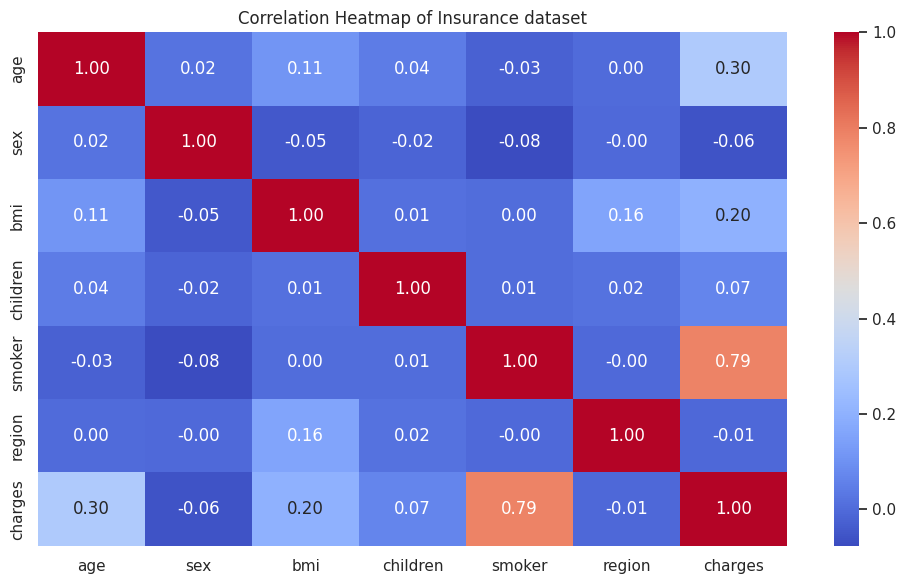

In [ ]:
df_encoded = df.copy()

df_encoded["sex"] = df_encoded["sex"].map({"male":0, "female": 1})
df_encoded["smoker"] = df_encoded["smoker"].map({"no":0, "yes": 1})
df_encoded["region"] = df_encoded["region"].astype("category").cat.codes

corr_matrix = df_encoded.corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0)
plt.title("Correlation Heatmap of Insurance dataset")
plt.tight_layout()
plt.show()

Interpretation:
- Charges have a strong positive correlation with smoker. Somokers usually pay much more.
- Age also has a moderate positive correlation with charges. Older people tend to have higher costs.
- Other features like sex and region have little effect on charges.

**3.Age vs Charges Scatter Plot**

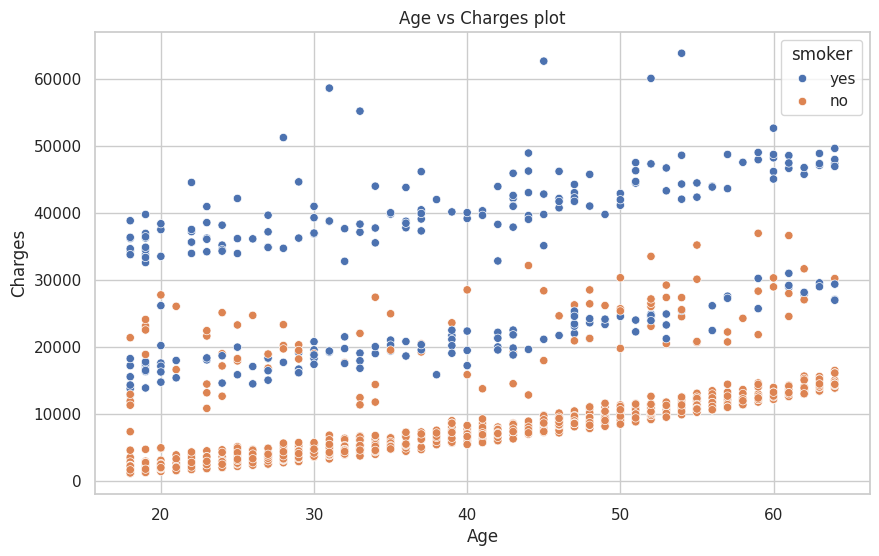

In [ ]:
sns.scatterplot(x='age', y="charges", hue="smoker", data=df)
plt.xlabel("Age")
plt.ylabel("Charges")
plt.title("Age vs Charges plot")
plt.show()

Interpretation:
- Charges generally increase with age, but the increase is much higher for smokers.
- Both age and smoking status are important factors affecting insurance charges.

## TODO A3: Feature Preparation (5 Marks)
**You must:**
- Train-test split
- Scaling (if applicable)

**Marks:** Correct split (3), Explanation (2)


**1.Train-test split**

In [ ]:
# TODO: Prepare features
X = df_encoded.drop("charges", axis=1)
y = df_encoded["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Explanation:
- We split the data so that 80% is used to train the model and 20% to test the performance.
- `random_state=42` ensures the split is reproducible.

**2.Feature Scaling**

In [ ]:
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

num_features = ["age", "bmi", "children"]

X_train_scaled[num_features] = scaler.fit_transform(X_train[num_features])
X_test_scaled[num_features] = scaler.transform(X_test[num_features])

Explanation:
- Numeric features like age, bmi and children have different ranges, so scaling puts them on a similar scale to help the model learn better.
- We fit the scaler only on training data to avoid data leakage.

## TODO A4: Multiple Linear Regression (8 Marks)
**You must:**
- Train model
- Evaluate using RMSE, MAE, R²

**Marks:** Model (4), Metrics (4)


**1.Train model**

In [ ]:
# TODO: Multiple Linear Regression
model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

**2.Evaluate the Model**

In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Evaluate with Multiple Linear Regression Results:")
print("Root Mean Squared Error (RMSE):", rmse)
print("Mean Absolute Error (MSE):", mae)
print("R-squared (R²):", r2)

Evaluate with Multiple Linear Regression Results:
Root Mean Squared Error (RMSE): 5799.587091438356
Mean Absolute Error (MSE): 4186.508898366433
R-squared (R²): 0.7833463107364539


## TODO A5: Polynomial Regression (7 Marks)
**You must:**
- Apply polynomial features
- Compare with linear regression

**Marks:** Implementation (4), Comparison (3)


**1.Applied Polynomial Features**

In [ ]:
# TODO: Polynomial Regression
poly_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lin_reg', LinearRegression())
])

poly_model.fit(X_train_scaled, y_train)
y_poly_pred = poly_model.predict(X_test_scaled)

rmse_poly = np.sqrt(mean_squared_error(y_test, y_poly_pred))
mae_poly = mean_absolute_error(y_test, y_poly_pred)
r2_poly = r2_score(y_test, y_poly_pred)

print("Polynomial Regression (Pipeline) Results")
print("Root Mean Squared Error (RMSE):", rmse_poly)
print("Mean Absolute Error (MSE):", mae_poly)
print("R-squared (R²):", r2_poly)

Polynomial Regression (Pipeline) Results
Root Mean Squared Error (RMSE): 4531.071500534054
Mean Absolute Error (MSE): 2730.315581680437
R-squared (R²): 0.867756671853774


**2. Comparison:**
- Polynomial regression performs better than linear regression, with lower errors(RMSE 4531 vs 5799, MAE 2730 vs 4187)
- It also has a higher R² (0.87 vs 0.78), meaning it explains more variation in insurance charges.
- This shows that using polynomial features helps the model understand the non-linear patterns in the data, so it perdicts insurance costs more accurately.

## TODO A6: Support Vector Regression (7 Marks)
**You must:**
- Train SVR (RBF kernel)
- Evaluate performance
- Justify kernel choice

**Marks:** Model (4), Justification (3)


**1.Train the model**

In [ ]:
# TODO: Support Vector Regression
svr_model = SVR(kernel='rbf', C=100, epsilon=0.1, gamma='scale')
svr_model.fit(X_train_scaled, y_train)
y_svr_pred = svr_model.predict(X_test_scaled)

**2.Evaluate performance**

In [ ]:
rmse_svr = np.sqrt(mean_squared_error(y_test, y_svr_pred))
mae_svr = mean_absolute_error(y_test, y_svr_pred)
r2_svr = r2_score(y_test, y_svr_pred)

print("SVR (RBF Kernel) Results")
print("Root Mean Squared Error (RMSE):", rmse_svr)
print("Mean Absolute Error (MSE):", mae_svr)
print("R-squared (R²):", r2_svr)

SVR (RBF Kernel) Results
Root Mean Squared Error (RMSE): 12203.700490946623
Mean Absolute Error (MSE): 6281.779505457665
R-squared (R²): 0.04069872750862025


**3.Justification for Using RBF Kernel**
- The RBF kernel is good at handling non-linear relationships, which exist in insurance data.
- The RBF kernel can learn curved patterns better than a liner kernel.
- It works well when we don't know the exact shape of the relationship between features and target

## TODO A7: Random Forest Regressor (8 Marks)
**You must:**
- Train Random Forest
- Evaluate model

**Marks:** Model (4), Evaluation (4)


**1.Train Random Forest Model**

In [ ]:
# TODO: Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)
y_rf_pred = rf_model.predict(X_test)

**2.Evaluate Model**

In [ ]:
rmse_rf = np.sqrt(mean_squared_error(y_test, y_rf_pred))
mae_rf = mean_absolute_error(y_test, y_rf_pred)
r2_rf = r2_score(y_test, y_rf_pred)

print("Random Forest Regressor Results")
print("Root Mean Squared Error (RMSE):", rmse_rf)
print("Mean Absolute Error (MSE):", mae_rf)
print("R-squared (R²):", r2_rf)

Random Forest Regressor Results
Root Mean Squared Error (RMSE): 4595.5680520539445
Mean Absolute Error (MSE): 2533.1799395613193
R-squared (R²): 0.8639650996299575


# 🟠 PART B: Classification Task (45 Marks)
You will work with the provided **classification dataset**.


## TODO B1: Dataset Understanding (5 Marks)
**You must:**
- Load dataset
- Show class distribution
- Comment on imbalance

**Marks:** Analysis (3), Explanation (2)


**1.Load Dataset**

In [ ]:
# TODO: Load classification dataset

df2 = pd.read_csv("/content/loan_data.csv")

print(df2.shape)
df2.head()

(45000, 14)


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


**2.Class Distribution**

In [ ]:
cls_count = df2["loan_status"].value_counts()
print(cls_count)

cls_percent = df2["loan_status"].value_counts(normalize=True) * 100
print(cls_percent)

loan_status
0    35000
1    10000
Name: count, dtype: int64
loan_status
0    77.777778
1    22.222222
Name: proportion, dtype: float64


**3.Comment on imbalance**

- The dataset has two classes: `0` = Rejected, `1` = Approved
- Most loans are rejected(35000) and fewer are approved(10000). In percentage: 78% rejected vs 22% approved. It means classes are not balanced.
- This imbalance means a model could predict rejections more easily and might struggle with predicting approvals.

## TODO B2: Exploratory Data Analysis (5 Marks)
**You must:**
- Plot class counts
- Plot at least one feature vs class

**Marks:** Plots (5),


**1.Plot Class Counts**

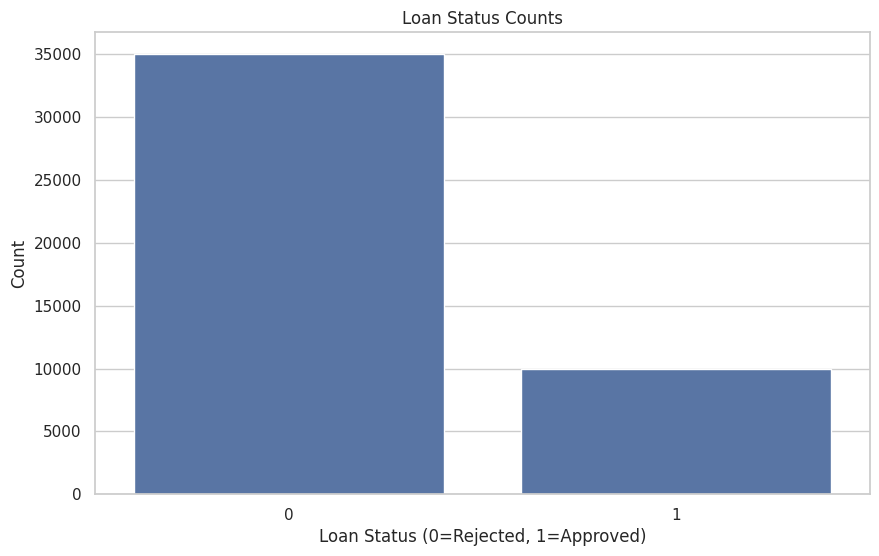

In [ ]:
# TODO: Classification EDA
sns.countplot(x="loan_status", data=df2)
plt.xlabel('Loan Status (0=Rejected, 1=Approved)')
plt.ylabel('Count')
plt.title("Loan Status Counts")
plt.show()

**2.`loan_status` vs `person_income` Box plot**

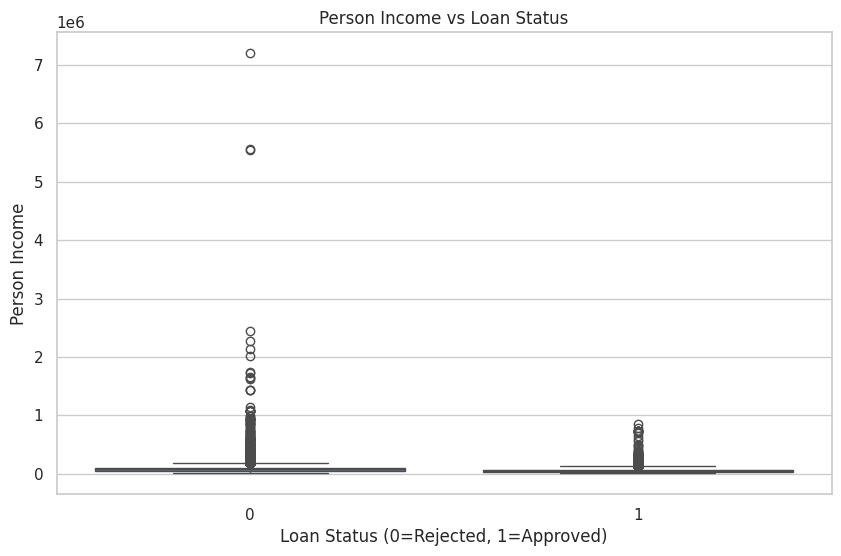

In [ ]:
sns.boxplot(x='loan_status', y="person_income", data=df2)
plt.xlabel('Loan Status (0=Rejected, 1=Approved)')
plt.ylabel("Person Income")
plt.title("Person Income vs Loan Status")
plt.show()

## TODO B3: Feature Preparation (5 Marks)
**You must:**
- Encoding (if needed)
- Scaling
- Train-test split with stratification




**1.Encoding**

In [ ]:
# TODO: Prepare classification features
cat_cols = [
  'person_gender',
  'person_education',
  'person_home_ownership',
  'loan_intent',
  'previous_loan_defaults_on_file'
]

df2_encoded = pd.get_dummies(df2, columns=cat_cols, drop_first=True, dtype=int)

**2.Train-test split (with stratification)**

In [ ]:
X = df2_encoded.drop('loan_status', axis=1)
y = df2_encoded['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

**3.Scaling**

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## TODO B4: Logistic Regression with L2 (8 Marks)
**You must:**
- Train Logistic Regression
- Evaluate using Accuracy, Precision, Recall
- Show Confusion Matrix

**Marks:** Model (4), Metrics (4)


**1.Train Logistic Regression**

In [ ]:
# TODO: Logistic Regression
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train_scaled, y_train)
y_pred = clf.predict(X_test_scaled)

**2.Evaluate using Accuracy, Precision, Recall**

In [ ]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)

print("Logistic Regression Results:")
print("Accuracy:", acc)
print("Pricision:", prec)
print("Recall:", rec)

Logistic Regression Results:
Accuracy: 0.8997777777777778
Pricision: 0.7895569620253164
Recall: 0.7485


**3.Confusion Matrix**

Confusion Matrix:
 [[6601  399]
 [ 503 1497]]


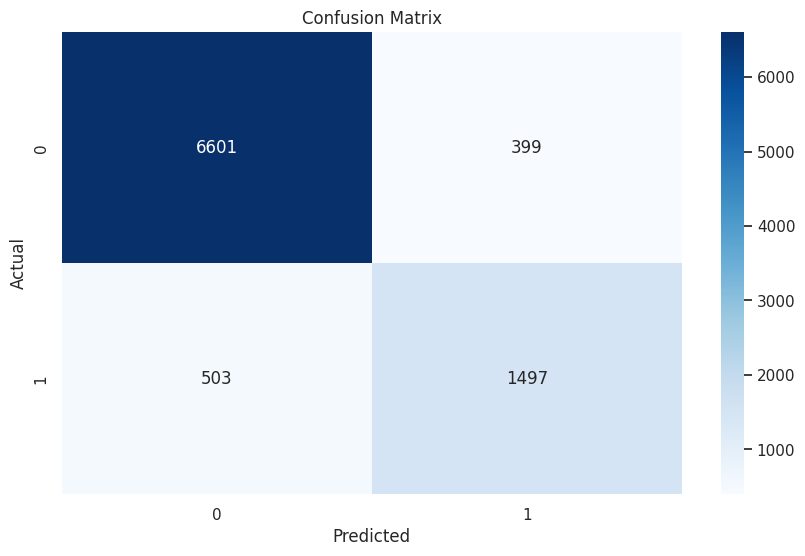

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## TODO B5: Support Vector Machine (7 Marks)
**You must:**
- Train SVM (Linear or RBF)
- Evaluate

**Marks:** Model (4), Evaluation (3)


**1.Train SVM with RBF**

In [ ]:
# TODO: SVM Classification
svm_model = SVC(kernel='rbf', C=1.0, gamma = 'scale', random_state=42)
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

**2.Evaluate**

In [ ]:
acc_svm = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm)
rec_svm = recall_score(y_test, y_pred_svm)

print("Support Vector Machine Results:")
print("Accuracy:", acc_svm)
print("Pricision:", prec_svm)
print("Recall:", rec_svm)

Support Vector Machine Results:
Accuracy: 0.916
Pricision: 0.849438202247191
Recall: 0.756


**3.Confusion Matrix with SVM**

Confusion Matrix with SVM:
 [[6732  268]
 [ 488 1512]]


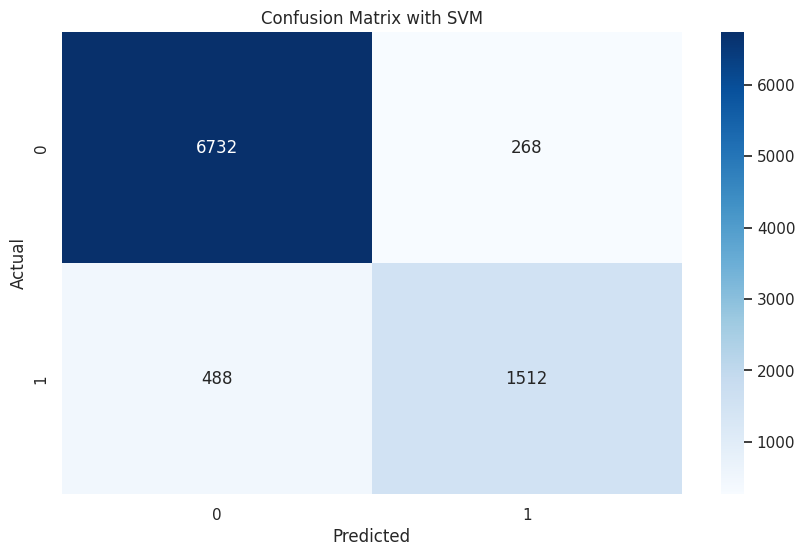

In [ ]:
cm_svm = confusion_matrix(y_test, y_pred_svm)
print("Confusion Matrix with SVM:\n", cm_svm)

sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix with SVM")
plt.show()

## TODO B6: Naive Bayes (5 Marks)
**You must:**
- Choose correct NB variant



**1.Train with Gaussian Naive Bayes**

In [ ]:
# TODO: Naive Bayes
gnb_model = GaussianNB()
gnb_model.fit(X_train_scaled, y_train)
y_pred_gnb = gnb_model.predict(X_test_scaled)

**2.Evaluate with Gaussian Naive Bayes**

In [ ]:
acc_gnb = accuracy_score(y_test, y_pred_gnb)
prec_gnb = precision_score(y_test, y_pred_gnb)
rec_gnb = recall_score(y_test, y_pred_gnb)

print("Gaussian Naive Bayes Results:")
print("Accuracy:", acc_gnb)
print("Pricision:", prec_gnb)
print("Recall:", rec_gnb)

Gaussian Naive Bayes Results:
Accuracy: 0.753
Pricision: 0.47310012062726176
Recall: 0.9805


**3.Confusion Matrix with Gaussian Naive Bayes**

Confusion Matrix with Gaussian Naive Bayes:
 [[4816 2184]
 [  39 1961]]


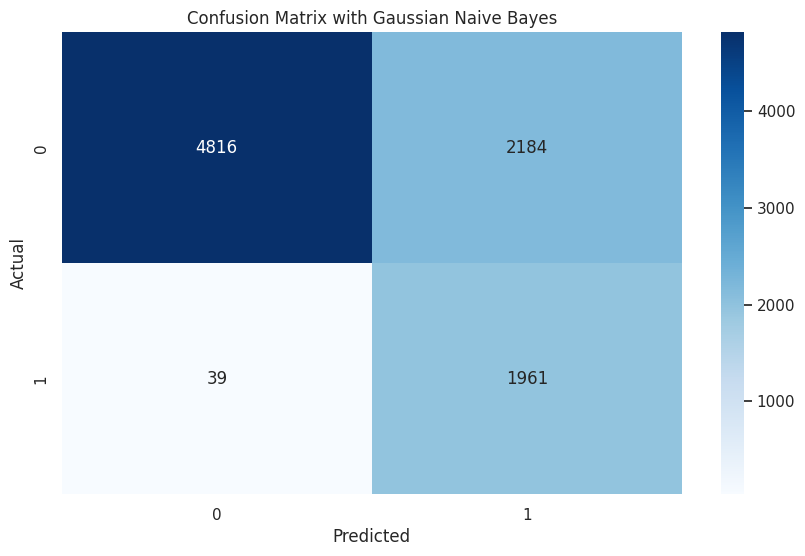

In [ ]:
cm_gnb = confusion_matrix(y_test, y_pred_gnb)
print("Confusion Matrix with Gaussian Naive Bayes:\n", cm_gnb)

sns.heatmap(cm_gnb, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix with Gaussian Naive Bayes")
plt.show()

## TODO B7: K-Nearest Neighbors (5 Marks)
**You must:**
- Try multiple K values
- Plot accuracy vs K

**Marks:** Experiment (3), Plot & choice (2)


**1. Train KNN with Multiple K Values**

In [ ]:
# TODO: KNN
k_values = range(1, 42)
accs = []

for k in k_values:
  knn_model = KNeighborsClassifier(n_neighbors=k)
  knn_model.fit(X_train_scaled, y_train)
  y_pred_knn = knn_model.predict(X_test_scaled)
  accs.append(accuracy_score(y_test, y_pred_knn))

print(accs)

[0.8756666666666667, 0.8793333333333333, 0.8888888888888888, 0.8886666666666667, 0.894, 0.8945555555555555, 0.8972222222222223, 0.8933333333333333, 0.8968888888888888, 0.8957777777777778, 0.8983333333333333, 0.8958888888888888, 0.8994444444444445, 0.8965555555555556, 0.8978888888888888, 0.8961111111111111, 0.8986666666666666, 0.8973333333333333, 0.8978888888888888, 0.8983333333333333, 0.9005555555555556, 0.8972222222222223, 0.8993333333333333, 0.898, 0.9006666666666666, 0.8981111111111111, 0.9, 0.8994444444444445, 0.9008888888888889, 0.8988888888888888, 0.9, 0.8985555555555556, 0.899, 0.8967777777777778, 0.8963333333333333, 0.8946666666666667, 0.8971111111111111, 0.8964444444444445, 0.8965555555555556, 0.8952222222222223, 0.896]


**2.Plot accuracy vs K**

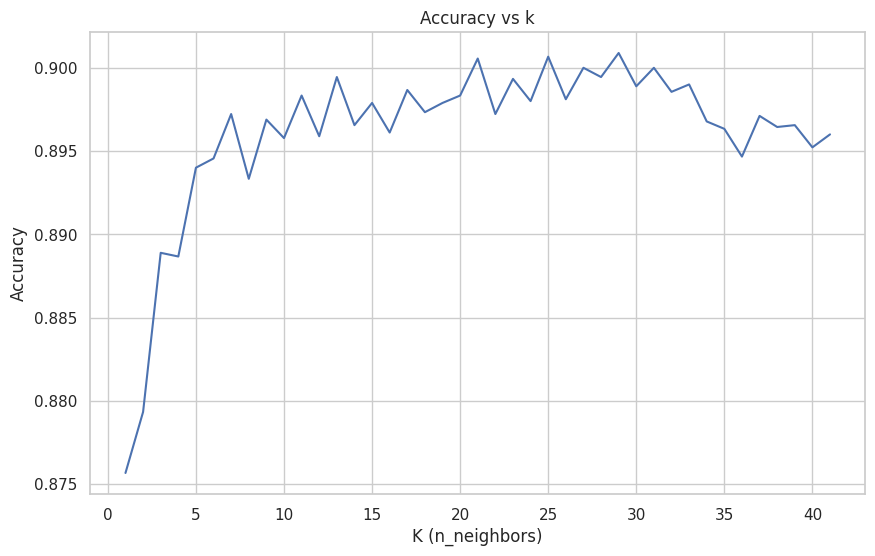

In [ ]:
plt.plot(list(k_values), accs)
plt.xlabel("K (n_neighbors)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs k")
plt.show()

**3.Best K value**

In [ ]:
best_k = list(k_values)[int(np.argmax(accs))]
print("Best k value:", best_k)
print("Best Accuracy:", float(np.max(accs)))

Best k value: 29
Best Accuracy: 0.9008888888888889


**4. Evaluate with KNN**

In [ ]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

acc_knn = accuracy_score(y_test, y_pred_knn)
prec_knn = precision_score(y_test, y_pred_knn)
rec_knn = recall_score(y_test, y_pred_knn)

print("K-Nearest Neighbors Results:")
print("Accuracy:", acc_knn)
print("Pricision:", prec_knn)
print("Recall:", rec_knn)

K-Nearest Neighbors Results:
Accuracy: 0.9008888888888889
Pricision: 0.8528662420382166
Recall: 0.6695


## TODO B8: Random Forest Classifier (5 Marks)
**You must:**
- Train model
- Show feature importance

**Marks:** Model (3), Interpretation (2)


**1. Train Model**

In [ ]:
# TODO: Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

**2. Evaluate with Random Forest Classifier**

In [ ]:
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)

print("Random Forest Classifier Results:")
print("Accuracy:", acc_rf)
print("Pricision:", prec_rf)
print("Recall:", rec_rf)

Random Forest Classifier Results:
Accuracy: 0.9286666666666666
Pricision: 0.8952270081490105
Recall: 0.769


**2. Feature Importance**

In [ ]:
importances = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importances.head(10)

,0
previous_loan_defaults_on_file_Yes,0.218127
loan_percent_income,0.163793
loan_int_rate,0.157401
person_income,0.124549
loan_amnt,0.061482
person_home_ownership_RENT,0.056364
credit_score,0.054492
person_age,0.031961
person_emp_exp,0.028429
cb_person_cred_hist_length,0.026421


**3.Top 10 Feature Importances**

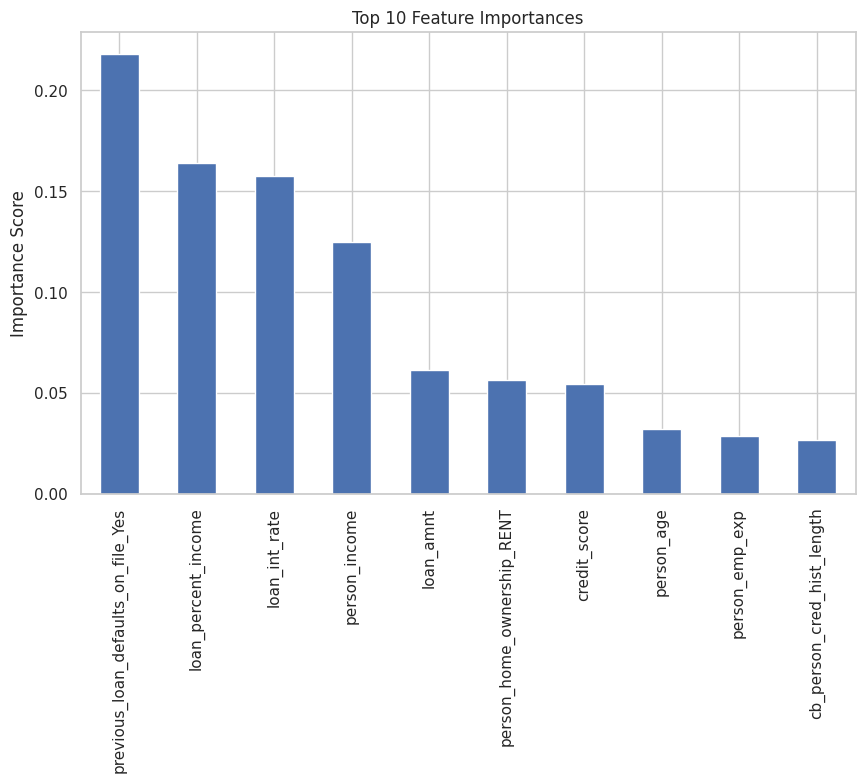

In [ ]:
importances.head(10).plot(kind="bar")
plt.ylabel("Importance Score")
plt.title("Top 10 Feature Importances")
plt.show()

**Interpretation:**
- Previous loan default is the strongest factor in loan decisions.
- Loan percent of income and interest rate are also very important.
- Income and loan amount have a moderate impact.
- Age, experience and credit history matter less.

# 🧠 Final Reflection (5 Marks)
**Answer briefly:**
- Best regression model and why
- Best classification model and why
- One real-world deployment scenario


## TODO: Write your reflection here

**1. Best regression model and why:**
- Polynomial Regression(Pipeline) was the best. It had the lowest errors(RMSE ≈ 4531, MSE ≈ 2730) and the highest R² (~0.87).
- It can capture non-linear patterns in the data better than simple linear regression and even slightly better than Random Forest here.

**2.Best classification model and why**
- The Random Forest Classifier worked best. It gave the highest accuracy (≈93%) and precision (≈90%) while keeping a good recall (≈77%)
- It's good at handling both numeric and categorical data, finds patterns in complex relationships, and isn't easily affected by unusual data points.

**3.Real-world deployment scenario**
- Regression: Insurance companies can predict individual medical insurance costs based on features like age, BMI and smooking habits, helping with pricing and risk assessment.
- Classification: Banks can automatically predict loan approvals, saving time and ensuring consistent decisions.